In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,log_loss
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer, make_column_selector
from tqdm import tqdm
import os
os.chdir("/home/pgcp-ai/MachineLearning/Datasets/")

In [2]:
hr = pd.read_csv("HR_comma_sep.csv")
hr

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.10,0.77,6,247,4,0,1,0,sales,low
3,0.92,0.85,5,259,5,0,1,0,sales,low
4,0.89,1.00,5,224,5,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14990,0.40,0.57,2,151,3,0,1,0,support,low
14991,0.37,0.48,2,160,3,0,1,0,support,low
14992,0.37,0.53,2,143,3,0,1,0,support,low
14993,0.11,0.96,6,280,4,0,1,0,support,low


In [3]:
hr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14995 entries, 0 to 14994
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14995 non-null  float64
 1   last_evaluation        14995 non-null  float64
 2   number_project         14995 non-null  int64  
 3   average_montly_hours   14995 non-null  int64  
 4   time_spend_company     14995 non-null  int64  
 5   Work_accident          14995 non-null  int64  
 6   left                   14995 non-null  int64  
 7   promotion_last_5years  14995 non-null  int64  
 8   Department             14995 non-null  object 
 9   salary                 14995 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [4]:
hr.isna().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

In [9]:
ohe = OneHotEncoder(sparse_output = False, drop = 'first', handle_unknown = 'ignore').set_output(transform = 'pandas')
transformer = ColumnTransformer(transformers = [('OHE', ohe, make_column_selector(dtype_include = object))], 
                               remainder = 'passthrough', verbose_feature_names_out=False).set_output(transform='pandas')

In [10]:
X,y = hr.drop("left", axis = 1), hr["left"]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state = 26, stratify = y)

In [11]:
X_train = transformer.fit_transform(X_train)
X_test = transformer.transform(X_test)


In [12]:
l1 = len(X_train.columns)

In [13]:
features = np.arange(2,l1+1)
scores = []
for f in tqdm(features):
    for n in [25,50,75,100,125]:
        rf = RandomForestClassifier(max_features=f,n_estimators=n,random_state=26)
        rf.fit(X_train,y_train)
        y_pred = rf.predict(X_test)
        y_pred_prob = rf.predict_proba(X_test)
        scores.append([f,n,log_loss(y_test,y_pred_prob),accuracy_score(y_test,y_pred)])
df_scores = pd.DataFrame(scores,columns=["No. of Features","No. of Estimators","Log Loss","Accuracy"])
df_scores.sort_values("Log Loss")

100%|███████████████████████████████████████████| 17/17 [01:27<00:00,  5.13s/it]


,No. of Features,No. of Estimators,Log Loss,Accuracy
34,8,125,0.059209,0.988886
29,7,125,0.065063,0.988886
4,2,125,0.066838,0.986441
3,2,100,0.067065,0.986219
14,4,125,0.068592,0.988442
...,...,...,...,...
81,18,50,0.194595,0.988442
65,15,25,0.195440,0.987997
80,18,25,0.209273,0.988220
60,14,25,0.209279,0.987775


In [14]:
X_trans = transformer.fit_transform(X)

In [15]:
bm = RandomForestClassifier(max_features=8,random_state=26,n_estimators=125)
bm.fit(X_trans,y)

RandomForestClassifier(max_features=8, n_estimators=125, random_state=26)

In [16]:
bm.feature_importances_

array([0.00089616, 0.00111781, 0.00108554, 0.0011261 , 0.0008514 ,
       0.00054229, 0.00272971, 0.0023855 , 0.00293526, 0.00390244,
       0.00294261, 0.3872834 , 0.10944707, 0.1633096 , 0.13224833,
       0.18339512, 0.00319665, 0.00060503])

In [17]:
df = pd.DataFrame({"Features":X_trans.columns,"Importances":bm.feature_importances_})
df = df.sort_values('Importances',ascending=False)

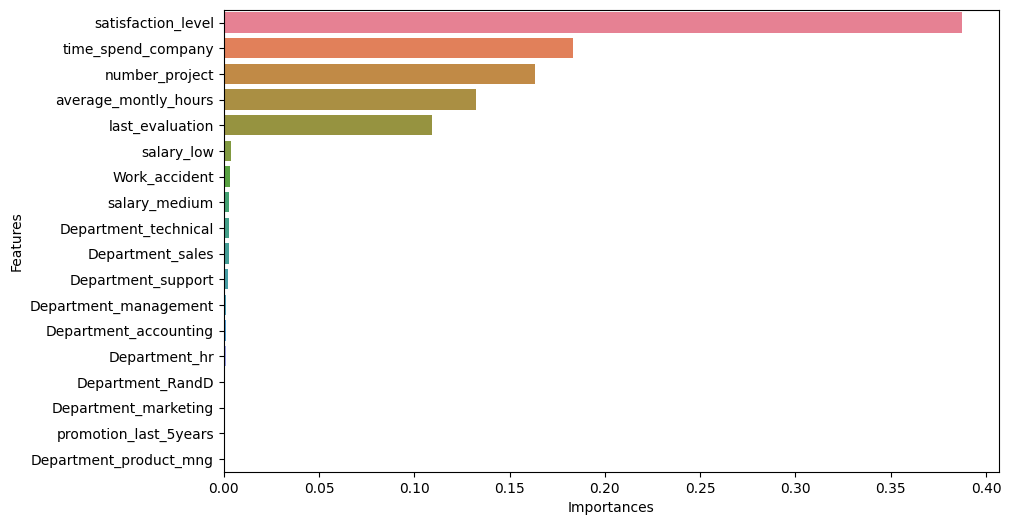

In [20]:
plt.figure(figsize=(10,6))
sns.barplot(data=df,y='Features',x='Importances',hue='Features')
plt.show()